In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Objective: Gain a deep understanding of phishing websites and how they operate.
Tasks:

*   Study the business problem and read literature on phishing.
*   Explore the dataset features and understand the characteristics.
*   Install required tools: Python, Jupyter Notebook, and libraries like pandas, numpy, matplotlib, scikit-learn.


In [ ]:
# Load Dataset
DF = pd.read_csv("/content/dataset_phishing.csv")

In [ ]:
# Top 5 rows in the Dataset
print(DF.head(5))

                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0                0                

In [ ]:
# Bottom 5 rows in the Dataset
print(DF.tail(5))

                                                     url  length_url  \
11425      http://www.fontspace.com/category/blackletter          45   
11426  http://www.budgetbots.com/server.php/Server%20...          84   
11427  https://www.facebook.com/Interactive-Televisio...         105   
11428             http://www.mypublicdomainpictures.com/          38   
11429  http://174.139.46.123/ap/signin?openid.pape.ma...         477   

       length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  \
11425               17   0        2           0      0      0       0      0   
11426               18   0        5           0      1      1       0      0   
11427               16   1        2           6      0      1       0      0   
11428               30   0        2           0      0      0       0      0   
11429               14   1       24           0      1      1       9      0   

       ...  domain_in_title  domain_with_copyright  whois_registered_domain  \
11425  

In [ ]:
# check for missing values
DF.isnull().sum()

,0
url,0
length_url,0
length_hostname,0
ip,0
nb_dots,0
...,...
web_traffic,0
dns_record,0
google_index,0
page_rank,0


In [ ]:
# Basic info about Dataset
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  114

In [ ]:
# Shape of dataset
DF.shape

(11430, 89)

In [ ]:
# columns name present in the Dataset
DF.columns

Index(['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens',
       'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore',
       'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma',
       'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com',
       'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url',
       'ratio_digits_host', 'punycode', 'port', 'tld_in_path',
       'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains',
       'prefix_suffix', 'random_domain', 'shortening_service',
       'path_extension', 'nb_redirection', 'nb_external_redirection',
       'length_words_raw', 'char_repeat', 'shortest_words_raw',
       'shortest_word_host', 'shortest_word_path', 'longest_words_raw',
       'longest_word_host', 'longest_word_path', 'avg_words_raw',
       'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand',
       'brand_in_subdomain', 'brand_in_path', 'suspecious_tld',
       'statistical_report', 

In [ ]:
# Give Summary statistics of Dataset
print(DF.describe(include="all"))

                                                      url    length_url  \
count                                               11430  11430.000000   
unique                                              11429           NaN   
top     http://e710z0ear.du.r.appspot.com/c:/users/use...           NaN   
freq                                                    2           NaN   
mean                                                  NaN     61.126684   
std                                                   NaN     55.297318   
min                                                   NaN     12.000000   
25%                                                   NaN     33.000000   
50%                                                   NaN     47.000000   
75%                                                   NaN     71.000000   
max                                                   NaN   1641.000000   

        length_hostname            ip       nb_dots    nb_hyphens  \
count      11430.000000  11430

# Objective: Analyze the dataset to find patterns, correlations, and anomalies.


*   Perform descriptive statistics on numerical and categorical features.
*   Use visualization tools like matplotlib and seaborn to create histograms, pair plots, and heatmaps.
*    Identify missing values, outliers, and imbalances.





In [ ]:
# Drop the 'url' column for numerical summary stats
numerical_df = DF.drop(columns=['url', 'status'])

# Summary statistics for numerical features
summary_stats = numerical_df.describe().T  # Transpose for better readability
summary_stats = summary_stats[['mean', '50%', 'std', 'min', 'max']] # 50% is the median

# Rename columns for clarity
summary_stats.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']

summary_stats.head(10)  # Show first 10 rows as a sample

,Mean,Median,Std Dev,Min,Max
length_url,61.126684,47.0,55.297318,12.0,1641.0
length_hostname,21.090289,19.0,10.777171,4.0,214.0
ip,0.150569,0.0,0.357644,0.0,1.0
nb_dots,2.480752,2.0,1.369686,1.0,24.0
nb_hyphens,0.997550,0.0,2.087087,0.0,43.0
nb_at,0.022222,0.0,0.155500,0.0,4.0
nb_qm,0.141207,0.0,0.364456,0.0,3.0
nb_and,0.162292,0.0,0.821337,0.0,19.0
nb_or,0.000000,0.0,0.000000,0.0,0.0
nb_eq,0.293176,0.0,0.998317,0.0,19.0


In [ ]:
# Insights into the central tendency, dispersion, and distribution of the data.

CT = DF.describe(include='all')
CT

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
count,11430,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.0,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,1.143000e+04,11430.000000,11430.000000,11430.000000,11430
unique,11429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,http://e710z0ear.du.r.appspot.com/c:/users/use...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,legitimate
freq,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5715
mean,NaN,61.126684,21.090289,0.150569,2.480752,0.997550,0.022222,0.141207,0.162292,0.0,...,0.775853,0.439545,0.072878,492.532196,4062.543745,8.567566e+05,0.020122,0.533946,3.185739,NaN
std,NaN,55.297318,10.777171,0.357644,1.369686,2.087087,0.155500,0.364456,0.821337,0.0,...,0.417038,0.496353,0.259948,814.769415,3107.784600,1.995606e+06,0.140425,0.498868,2.536955,NaN
min,NaN,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000,NaN
25%,NaN,33.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,1.000000,0.000000,0.000000,84.000000,972.250000,0.000000e+00,0.000000,0.000000,1.000000,NaN
50%,NaN,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,1.000000,0.000000,0.000000,242.000000,3993.000000,1.651000e+03,0.000000,1.000000,3.000000,NaN
75%,NaN,71.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.0,...,1.000000,1.000000,0.000000,449.000000,7026.750000,3.738455e+05,0.000000,1.000000,5.000000,NaN


In [ ]:
# Frequency distribution and mode for categorical features
status_counts = DF['status'].value_counts()
status_mode = DF['status'].mode()[0]

# Display top 5 most frequent URLs as a sample
url_counts = DF['url'].value_counts().head(5)
url_mode = DF['url'].mode()[0]

status_counts, status_mode, url_counts, url_mode

(status
 legitimate    5715
 phishing      5715
 Name: count, dtype: int64,
 'legitimate',
 url
 http://e710z0ear.du.r.appspot.com/c:/users/user/downlo                            2
 http://office365-login-outlook.el.r.appspot.com/wp-content/xp.php                 1
 http://graceleadershipfoundation.org/modules/mod_simplefileuploadv1.3/connect/    1
 http://fience.vot.pl/xl                                                           1
 https://usbank.app.link/NquAmzCW01?platform=hootsuite                             1
 Name: count, dtype: int64,
 'http://e710z0ear.du.r.appspot.com/c:/users/user/downlo')

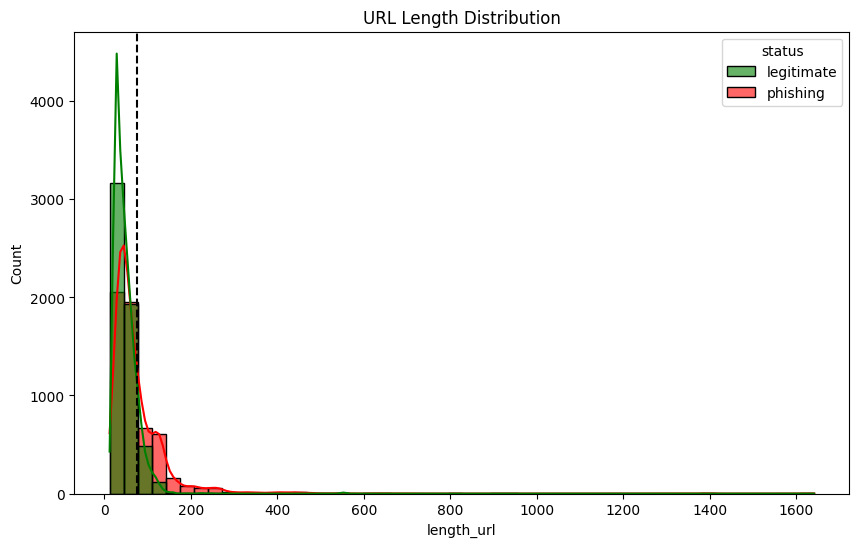

In [ ]:
# A. URL Length Distribution (length_url)
plt.figure(figsize=(10, 6))
sns.histplot(data=DF, x='length_url', hue='status', bins=50, kde=True, palette={'phishing': 'red', 'legitimate': 'green'},alpha=0.6)
plt.title('URL Length Distribution')
plt.axvline(x=75, color='black', linestyle='--', label='Threshold')
plt.show()

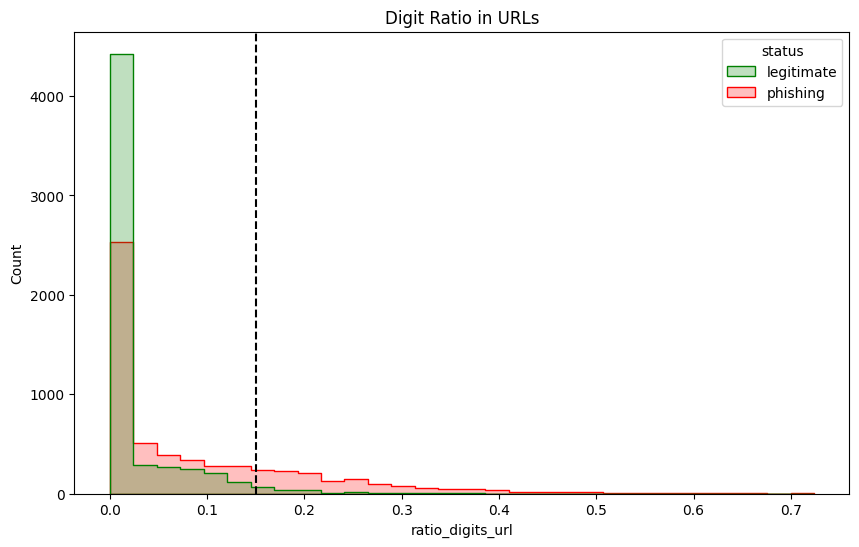

In [ ]:
# B. Digit Ratio in URLs (ratio_digits_url)
plt.figure(figsize=(10, 6))
sns.histplot(data=DF, x='ratio_digits_url', hue='status', bins=30, element='step',palette={'phishing': 'red', 'legitimate': 'green'})
plt.title('Digit Ratio in URLs')
plt.axvline(x=0.15, color='black', linestyle='--')
plt.show()

Text(0, 0.5, 'Count')

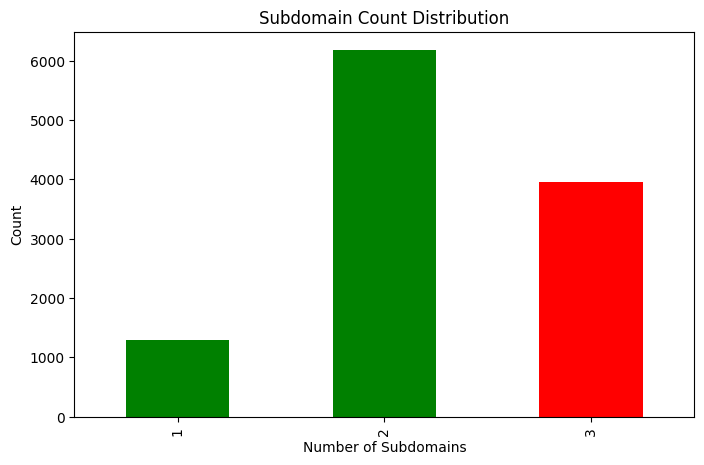

In [ ]:
# C. Number of Subdomains (nb_subdomains)
plt.figure(figsize=(8, 5))
DF['nb_subdomains'].value_counts().sort_index().plot(kind='bar', color=['green','green','red'])
plt.title('Subdomain Count Distribution')
plt.xlabel('Number of Subdomains')
plt.ylabel('Count')

Text(0.5, 1.0, 'Domain Age Distribution (Log Scale)')

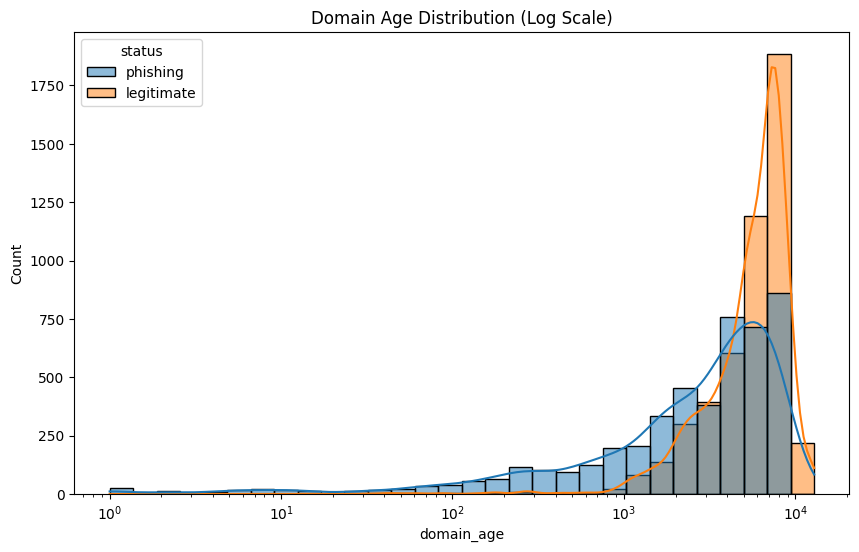

In [ ]:
# Domain age distribution (log scale)
plt.figure(figsize=(10, 6))
sns.histplot(data=DF[DF['domain_age']>0], x='domain_age', hue='status',bins=30, log_scale=True, kde=True)
plt.title('Domain Age Distribution (Log Scale)')

<Axes: xlabel='nb_www', ylabel='count'>

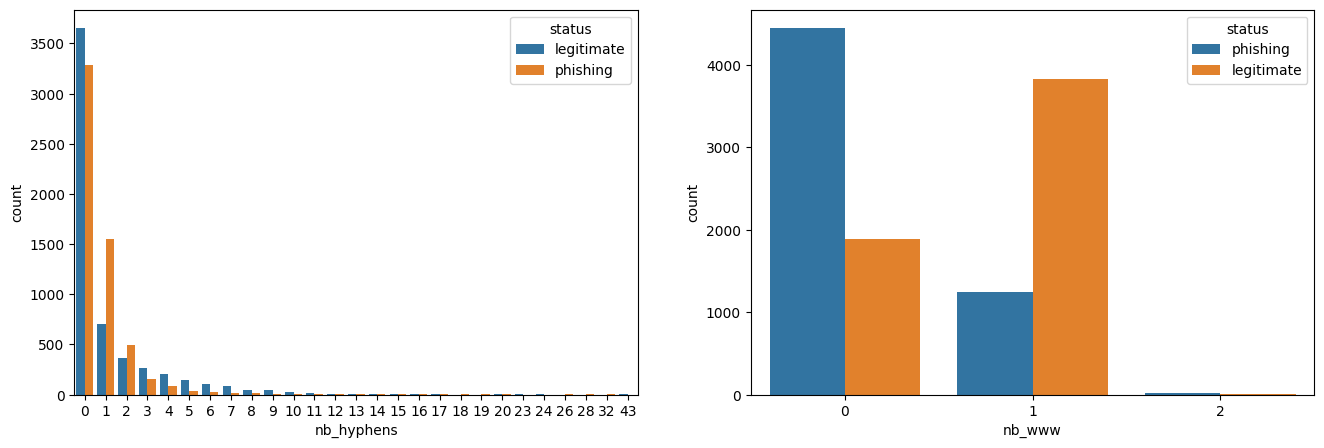

In [ ]:
# Hyphen and www counts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,5))
sns.countplot(data=DF, x='nb_hyphens', hue='status', ax=ax1)
sns.countplot(data=DF, x='nb_www', hue='status', ax=ax2)

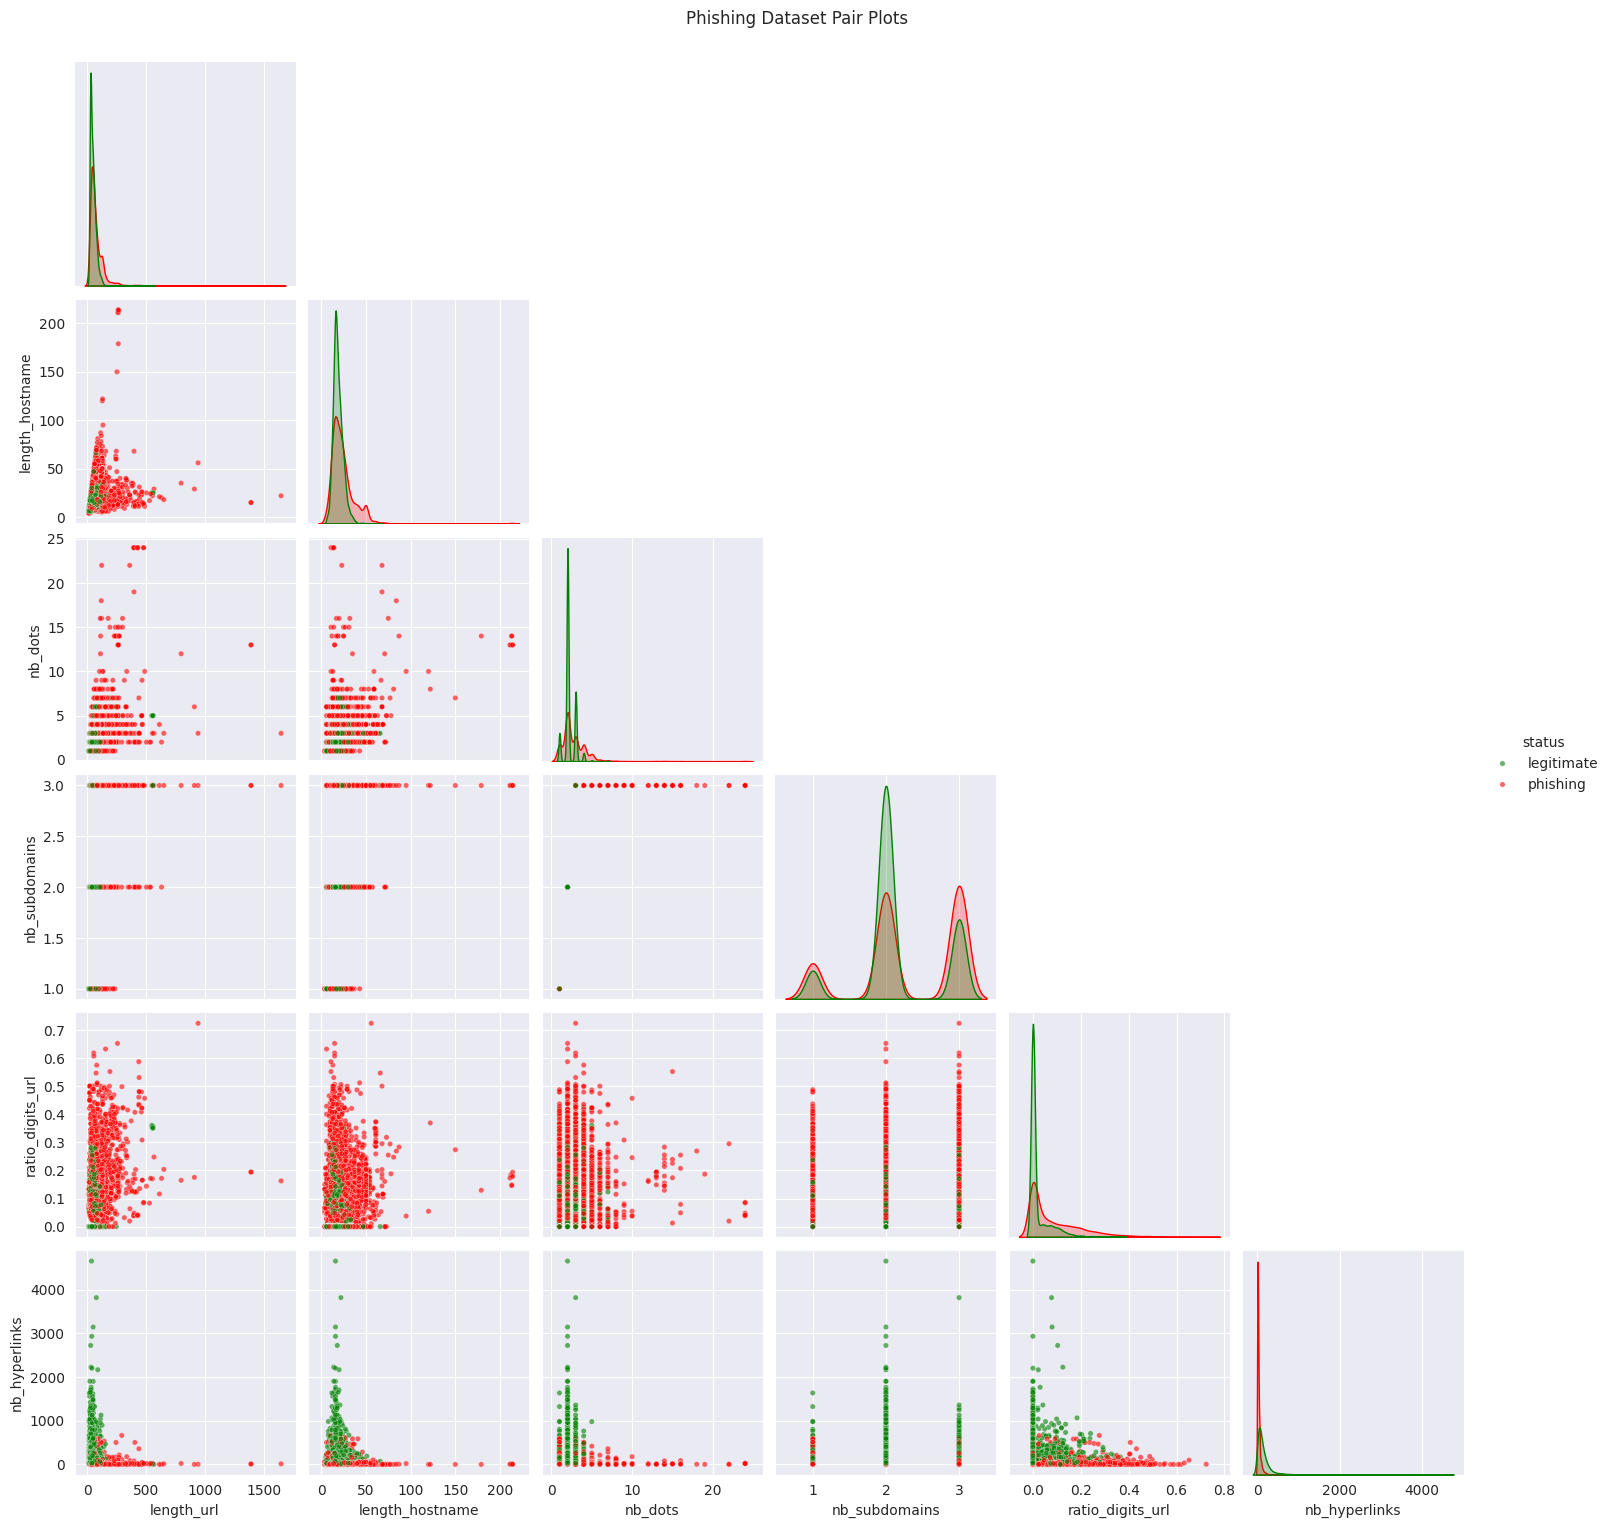

In [ ]:
# Select key numerical features
features = ['length_url', 'length_hostname', 'nb_dots',
            'nb_subdomains', 'ratio_digits_url', 'nb_hyperlinks']

# Create pair plot with phishing hue
sns.set_style("darkgrid")
sns.pairplot(DF[features + ['status']], hue='status', palette={'phishing': 'red', 'legitimate': 'green'},corner=True,plot_kws={'alpha': 0.6, 's': 15})
plt.suptitle('Phishing Dataset Pair Plots', y=1.02)
plt.show()

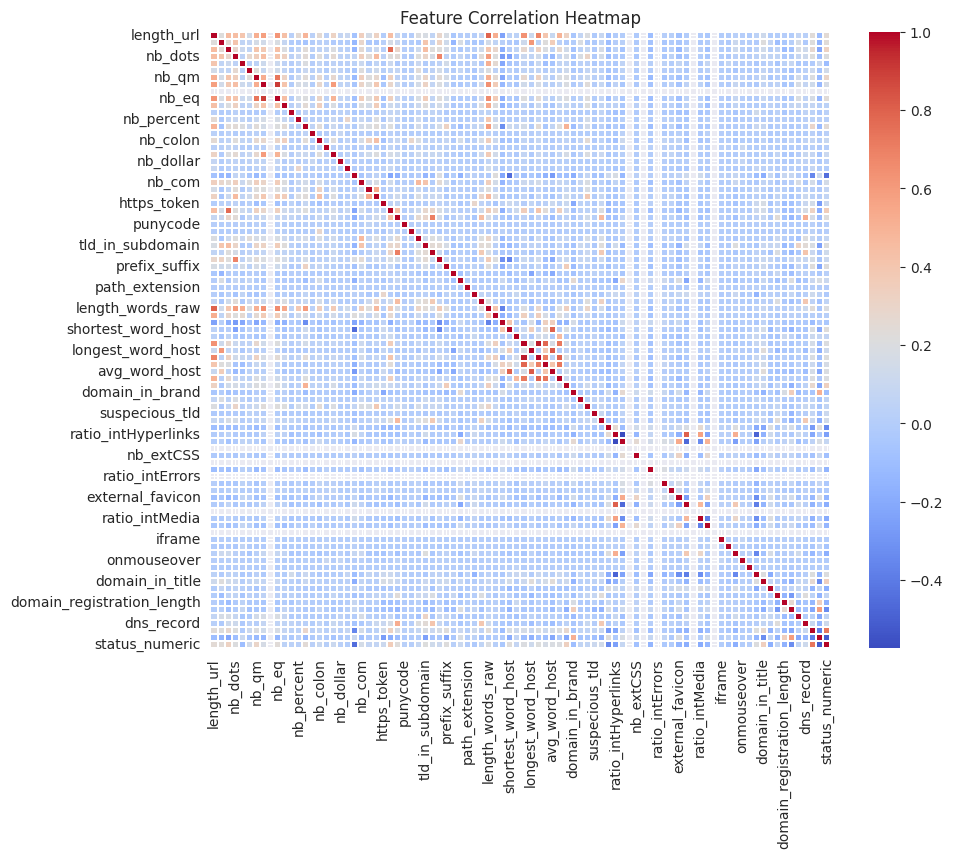

In [ ]:
# Encode target variable
status_mapping = {'legitimate': 0, 'phishing': 1}
DF['status_numeric'] = DF['status'].map(status_mapping)

# Compute correlation matrix for numerical features
correlation_matrix = DF.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, linewidths=0.1)
plt.title("Feature Correlation Heatmap")
plt.show()


# Objective: Prepare the dataset for model training.
Tasks:

*   Handle missing values and remove duplicates.
*   Perform feature encoding for categorical variables.
*   Normalize/scale numerical features.
*   Split the data into training and testing sets (e.g., 80-20 split).

In [ ]:
# Check basic info and missing values
missing_summary = DF.isnull().sum()
missing_percentage = (missing_summary / len(DF)) * 100

# Detect duplicates
duplicates = DF.duplicated()
duplicate_count = duplicates.sum()
duplicate_percentage = (duplicate_count / len(DF)) * 100

# Store original shape before removing duplicates
original_shape = DF.shape

# Remove duplicates
df_cleaned = DF.drop_duplicates()

# Prepare a summary of the analysis
{
    "missing_summary": missing_summary[missing_summary > 0],
    "missing_percentage": missing_percentage[missing_percentage > 0],
    "duplicate_count": duplicate_count,
    "duplicate_percentage": duplicate_percentage,
    "original_shape": original_shape,
    "new_shape_after_dropping_duplicates": df_cleaned.shape
}

{'missing_summary': Series([], dtype: int64),
 'missing_percentage': Series([], dtype: float64),
 'duplicate_count': np.int64(0),
 'duplicate_percentage': np.float64(0.0),
 'original_shape': (11430, 90),
 'new_shape_after_dropping_duplicates': (11430, 90)}

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset to apply encoding
DF = DF.copy()

# Apply label encoding to the 'status' column
label_encoder = LabelEncoder()
DF['status_encoded'] = label_encoder.fit_transform(DF['status'])

# Mapping dictionary for explanation
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Display mapping and sample of the encoded column
label_mapping, DF[['status', 'status_encoded']].head()


({'legitimate': np.int64(0), 'phishing': np.int64(1)},
        status  status_encoded
 0  legitimate               0
 1    phishing               1
 2    phishing               1
 3  legitimate               0
 4  legitimate               0)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Normalize numerical features using MinMaxScaler
scaler = MinMaxScaler()
# Select only numerical features for scalingDF[numerical_cols] = scaler.fit_transform(DF[numerical_cols])
numerical_cols = DF.select_dtypes(include=np.number).columns
DF[numerical_cols] = scaler.fit_transform(DF[numerical_cols])


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming df is the scaled and cleaned DataFrame
# Drop 'url' and separate features and target
X = DF.drop(['url', 'status'], axis=1)
y = DF['status']

# Perform stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Output the shape of the splits
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training class distribution:\n", y_train.value_counts(normalize=True))
print("Testing class distribution:\n", y_test.value_counts(normalize=True))


Training set shape: (9144, 89)
Testing set shape: (2286, 89)
Training class distribution:
 status
legitimate    0.5
phishing      0.5
Name: proportion, dtype: float64
Testing class distribution:
 status
phishing      0.5
legitimate    0.5
Name: proportion, dtype: float64


# Objective: Enhance the dataset with new features and improve predictive power.


  

*   Perform feature selection using correlation and feature importance.:
*   Create new features based on domain knowledge (e.g., length of URL, presence of special characters).


  



Deliverables: A refined dataset with engineered features and documentation.



In [ ]:
# Encode 'status' if not done already (if done, skip this)
DF['status'] = DF['status'].map({'legitimate': 0, 'phishing': 1})


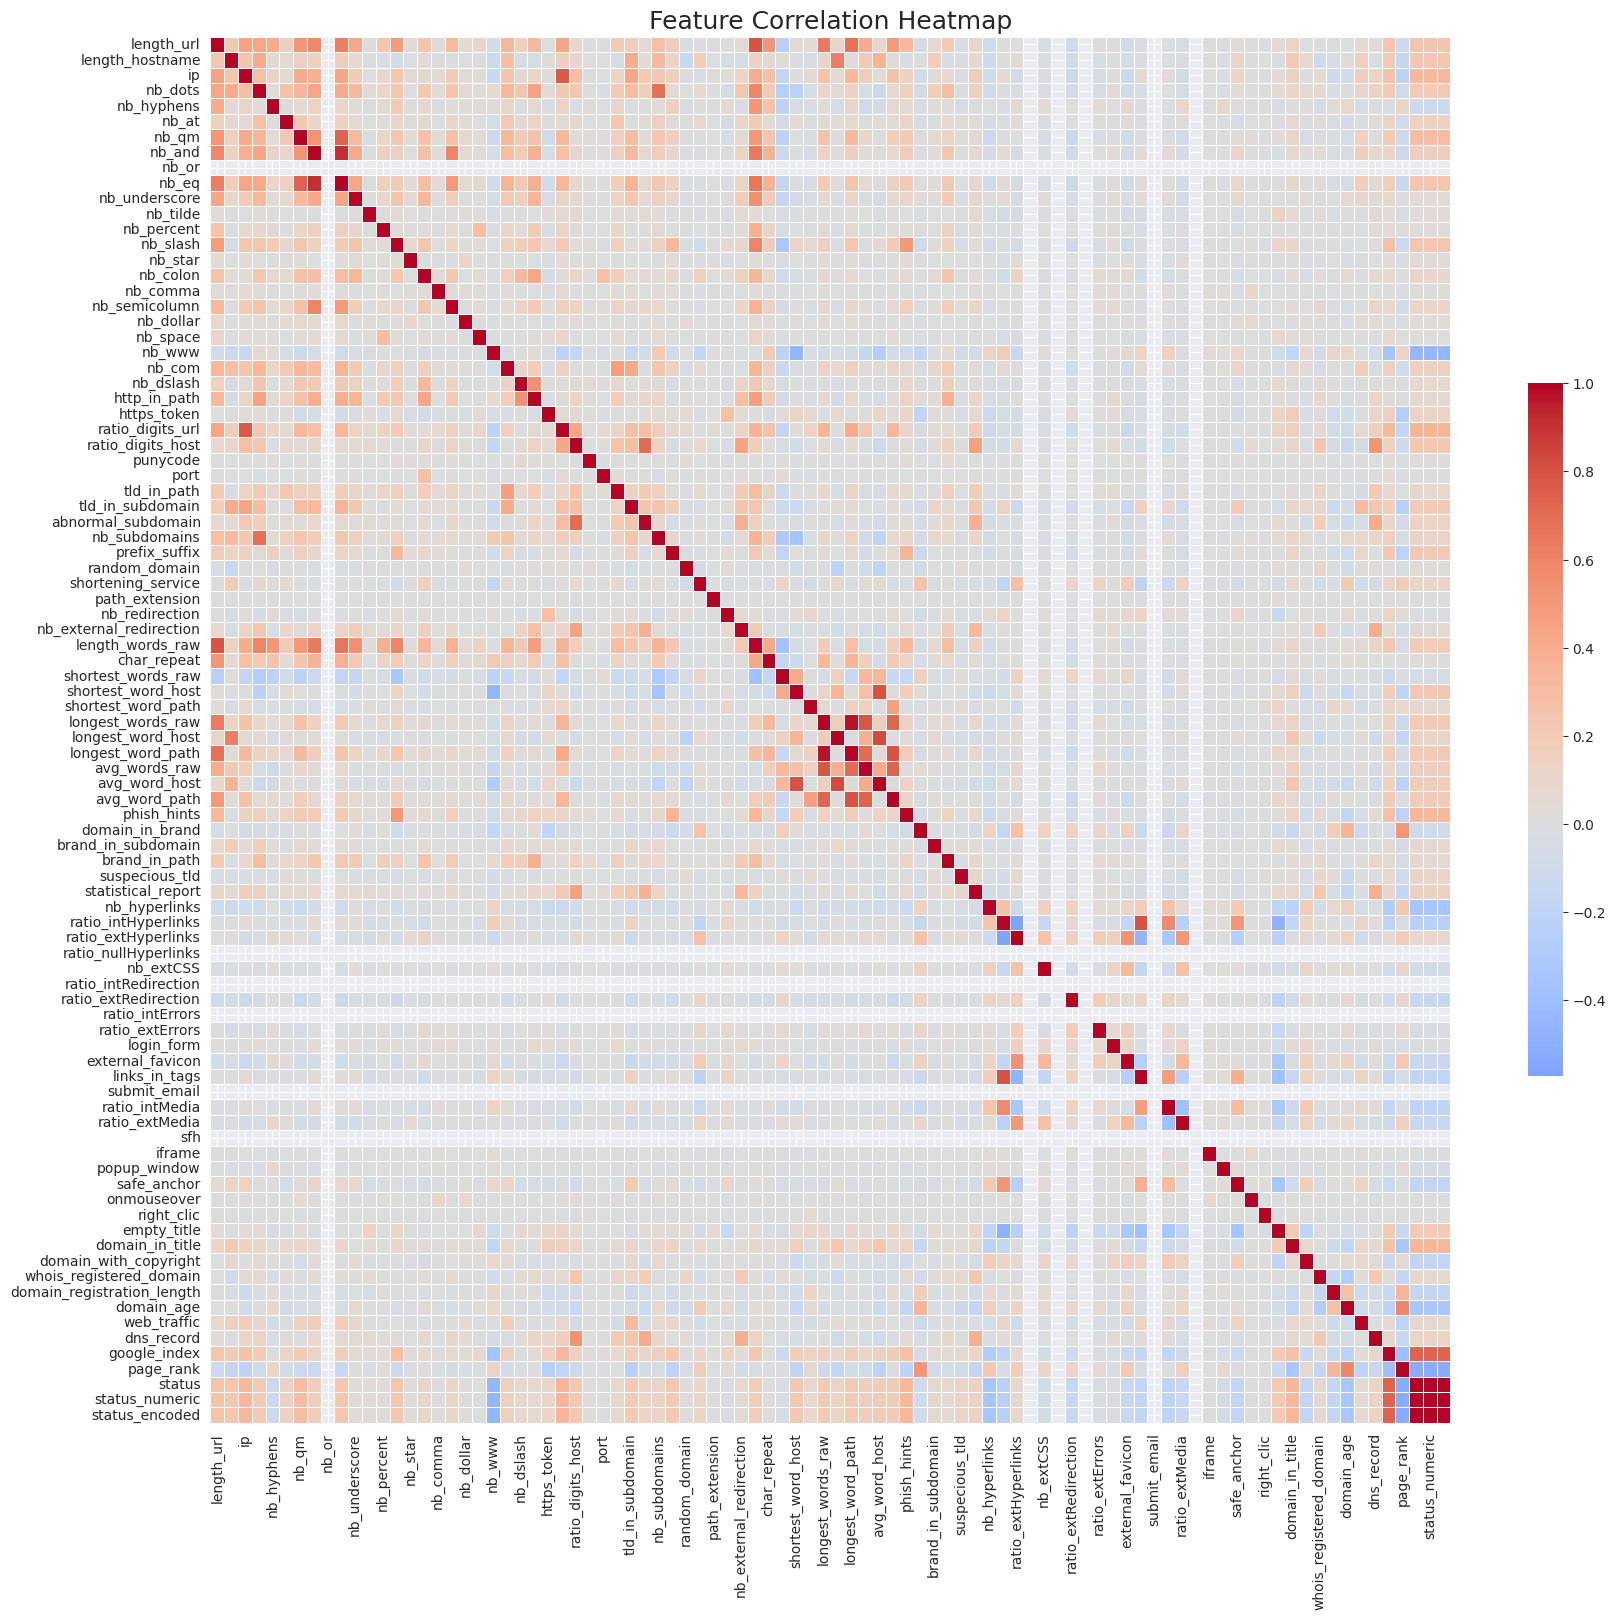

In [ ]:
# Compute Pearson correlation
corr_matrix = DF.select_dtypes(include=np.number).corr(method='pearson')

# Set plot size
plt.figure(figsize=(20, 18))

# Create the heatmap
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={"shrink": 0.5})
plt.title("Feature Correlation Heatmap", fontsize=18)
plt.show()


In [ ]:
# Extract upper triangle of the correlation matrix (without self-correlations)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.9 or < -0.9
high_corr = upper.stack().reset_index()
high_corr.columns = ['Feature_1', 'Feature_2', 'Correlation']
high_corr = high_corr[(high_corr['Correlation'] > 0.9) | (high_corr['Correlation'] < -0.9)]
high_corr.sort_values(by='Correlation', ascending=False, inplace=True)

print(high_corr)


              Feature_1          Feature_2  Correlation
3483             status     status_numeric     1.000000
3485     status_numeric     status_encoded     1.000000
3484             status     status_encoded     1.000000
2667  longest_words_raw  longest_word_path     0.968503
560              nb_and              nb_eq     0.906404


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
DF = pd.read_csv("dataset_phishing.csv")

# Drop non-numeric column
DF = DF.drop(columns=['url'])

# Encode target
DF['status'] = DF['status'].map({'legitimate': 0, 'phishing': 1})

# Split features and target
X = DF.drop('status', axis=1)
y = DF['status']


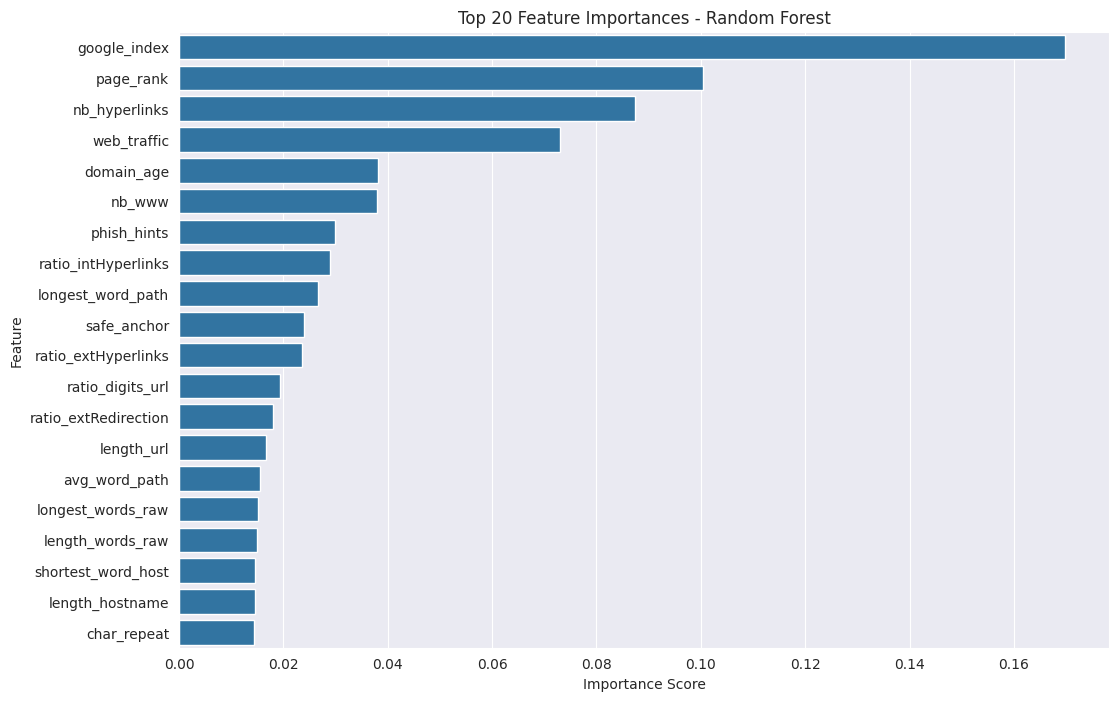

In [ ]:
# Random Forest Feature Importances
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances_rf = pd.Series(rf.feature_importances_, index=X.columns)
importances_rf = importances_rf.sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(12, 8))
sns.barplot(x=importances_rf[:20], y=importances_rf.index[:20])
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


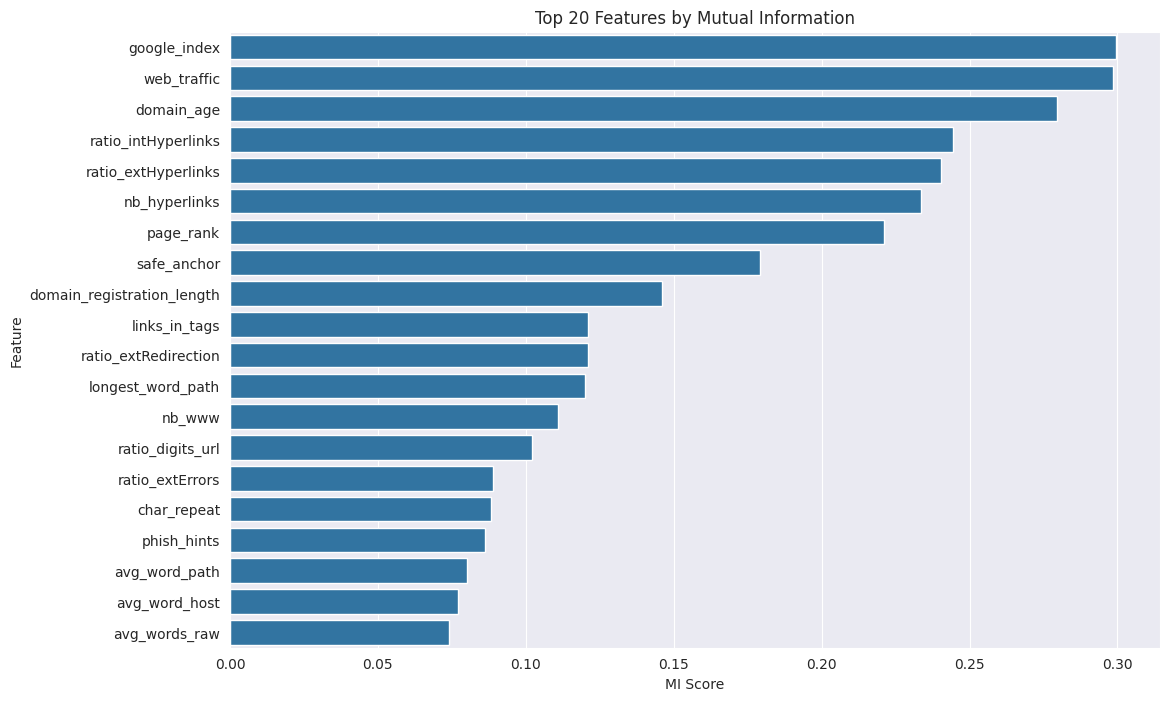

In [ ]:
# Mutual Information Scores
mi = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
importances_mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(12, 8))
sns.barplot(x=importances_mi[:20], y=importances_mi.index[:20])
plt.title("Top 20 Features by Mutual Information")
plt.xlabel("MI Score")
plt.ylabel("Feature")
plt.show()

In [ ]:
# Create new binary flag features
DF['long_url_flag'] = (DF['length_url'] > 75).astype(int)
DF['suspicious_digits_ratio'] = (DF['ratio_digits_url'] > 0.25).astype(int)
DF['many_subdomains_flag'] = (DF['nb_subdomains'] > 2).astype(int)
DF['young_domain_flag'] = (DF['domain_age'] < 365).astype(int)
DF['low_web_traffic_flag'] = (DF['web_traffic'] < 1000).astype(int)

# Special characters combined feature
special_char_features = ['nb_at', 'nb_qm', 'nb_and', 'nb_percent', 'nb_eq', 'nb_dollar', 'nb_semicolumn']
DF['high_special_chars'] = DF[special_char_features].sum(axis=1)

# Use phish_hints directly (optional)
DF['has_phish_hint'] = DF['phish_hints']

In [ ]:
# Correlation with target
new_features = ['long_url_flag', 'suspicious_digits_ratio', 'many_subdomains_flag',
                'young_domain_flag', 'low_web_traffic_flag', 'high_special_chars', 'has_phish_hint']

correlations = DF[new_features + ['status']].corr()['status'].drop('status').sort_values(ascending=False)
print(correlations)


low_web_traffic_flag       0.368436
has_phish_hint             0.335393
long_url_flag              0.246777
many_subdomains_flag       0.205312
suspicious_digits_ratio    0.201240
high_special_chars         0.200080
young_domain_flag          0.146410
Name: status, dtype: float64


<ipython-input-33-849a4a045709>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette="viridis")


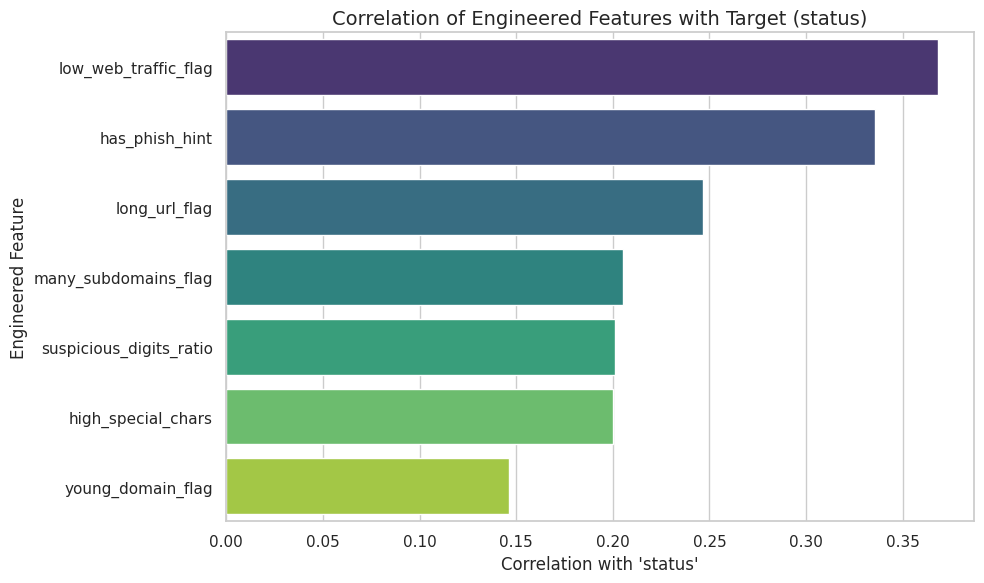

In [ ]:
# List of engineered features
engineered_features = [
    'long_url_flag',
    'suspicious_digits_ratio',
    'many_subdomains_flag',
    'young_domain_flag',
    'low_web_traffic_flag',
    'high_special_chars',
    'has_phish_hint'
]

# Compute correlation with target variable 'status'
correlations = DF[engineered_features + ['status']].corr()['status'].drop('status').sort_values(ascending=False)

# Plot correlation heatmap/barplot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.barplot(x=correlations.values, y=correlations.index, palette="viridis")
plt.title("Correlation of Engineered Features with Target (status)", fontsize=14)
plt.xlabel("Correlation with 'status'")
plt.ylabel("Engineered Feature")
plt.tight_layout()
plt.show()


In [ ]:
selected_original = [
    'google_index', 'page_rank', 'nb_hyperlinks', 'web_traffic', 'domain_age',
    'nb_www', 'ratio_intHyperlinks', 'ratio_extHyperlinks','domain_registration_length','safe_anchor',
    'ratio_digits_url', 'length_url', 'nb_subdomains','links_in_tags','ratio extRedirection',
    'longest_word_path','ratio_extErrors','char_repeat','phish_hints','avg_word_path','avg_word_host','avg_words_raw'
]
engineered_features = [
    'long_url_flag', 'suspicious_digits_ratio', 'many_subdomains_flag',
    'young_domain_flag', 'low_web_traffic_flag', 'high_special_chars',
    'has_phish_hint'
]


In [ ]:
# Load original data
DF = pd.read_csv("dataset_phishing.csv")

DF = DF.drop(columns=['url']) # Drop the non-numeric URL
# Encode the target variable
DF['status'] = DF['status'].map({'legitimate': 0, 'phishing': 1})

# Create engineered features
DF['long_url_flag'] = (DF['length_url'] > 75).astype(int)
DF['suspicious_digits_ratio'] = (DF['ratio_digits_url'] > 0.25).astype(int)
DF['many_subdomains_flag'] = (DF['nb_subdomains'] > 2).astype(int)
DF['young_domain_flag'] = (DF['domain_age'] < 365).astype(int)
DF['low_web_traffic_flag'] = (DF['web_traffic'] < 1000).astype(int)
DF['high_special_chars'] = DF[['nb_at', 'nb_qm', 'nb_and', 'nb_percent', 'nb_eq', 'nb_dollar', 'nb_semicolumn']].sum(axis=1)
DF['has_phish_hint'] = DF['phish_hints']

# Final selected features
selected_original = ['google_index', 'page_rank', 'nb_hyperlinks', 'web_traffic', 'domain_age','nb_www',
                     'ratio_intHyperlinks','ratio_extHyperlinks','domain_registration_length','safe_anchor',
                     'ratio_digits_url', 'length_url', 'nb_subdomains','links_in_tags','ratio_extRedirection', # Corrected column name here
                     'longest_word_path','ratio_extErrors','char_repeat','phish_hints','avg_word_path','avg_word_host','avg_words_raw']
engineered_features = [
    'long_url_flag', 'suspicious_digits_ratio', 'many_subdomains_flag','young_domain_flag', 'low_web_traffic_flag', 'high_special_chars','has_phish_hint']

final_features = selected_original + engineered_features + ['status']
refined_df = DF[final_features]

# Save refined dataset
refined_path = "final_refined_dataset.csv"
refined_df.to_csv(refined_path, index=False)
print(f"Refined dataset saved as {refined_path}")

Refined dataset saved as final_refined_dataset.csv


# Objective: Train and evaluate multiple machine learning models.

Deliverables: A trained model with evaluation metrics and a performance comparison report.



# Trained Machine Learning Model



In [ ]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.metrics import (precision_score,recall_score, f1_score, confusion_matrix,roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # For saving the model

In [ ]:
# Load Dataset
data = pd.read_csv('/content/dataset_phishing.csv')

# Encode Target Variable
data['status'] = data['status'].map({'legitimate': 0, 'phishing': 1})

# Drop non-numeric columns (like URL)
X = data.drop(columns=['url', 'status'])
y = data['status']

# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

# Best Estimator
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluation on Test Set
y_pred = best_model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

# Save the model
joblib.dump(best_model, 'phishing_model_final.pkl')
print("Model saved as phishing_model_final.pkl")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97      1143
           1       0.96      0.97      0.97      1143

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286

Accuracy: 0.9654418197725284
ROC AUC: 0.9654418197725284
Model saved as phishing_model_final.pkl


# Evaluation Metrics Report



In [ ]:
# Load model
model = joblib.load('/content/phishing_model_final.pkl')  # already trained & saved

# Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # for ROC and PR curves

# Print Classification Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97      1143
           1       0.96      0.97      0.97      1143

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286

Accuracy: 0.9654418197725284
Precision: 0.9618055555555556
Recall: 0.9693788276465442
F1-Score: 0.9655773420479303
ROC-AUC Score: 0.9943453590610886


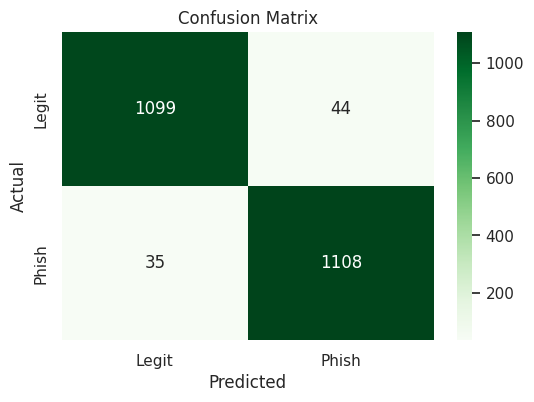

In [ ]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Legit', 'Phish'], yticklabels=['Legit', 'Phish'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

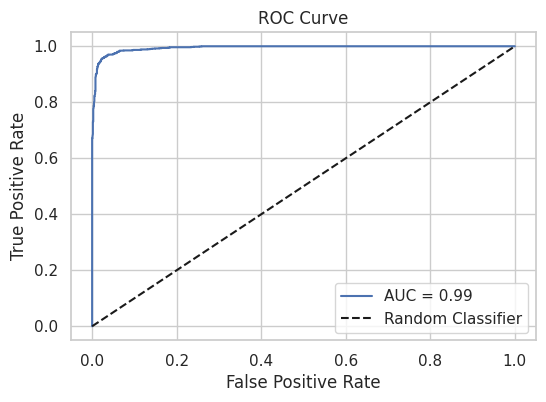

In [ ]:
# Step 6: Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

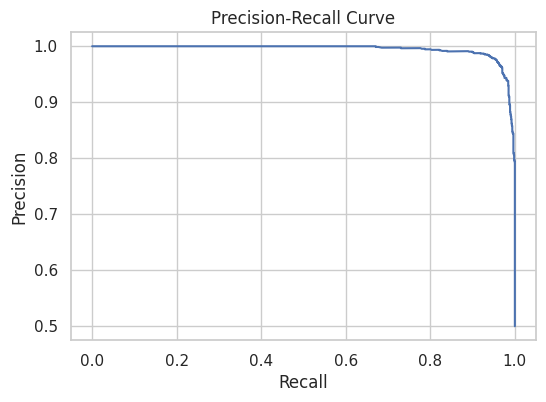

In [ ]:
# Step 7: Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

# Performance Comparison Report

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
results_df = pd.DataFrame(results)
print(results_df.sort_values(by="F1-Score", ascending=False))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:30:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
3              XGBoost  0.966317   0.961073  0.972003  0.966507  0.993604
2        Random Forest  0.962817   0.960801  0.965004  0.962898  0.993552
1        Decision Tree  0.933946   0.930556  0.937883  0.934205  0.933946
0  Logistic Regression  0.804899   0.806508  0.802275  0.804386  0.884585


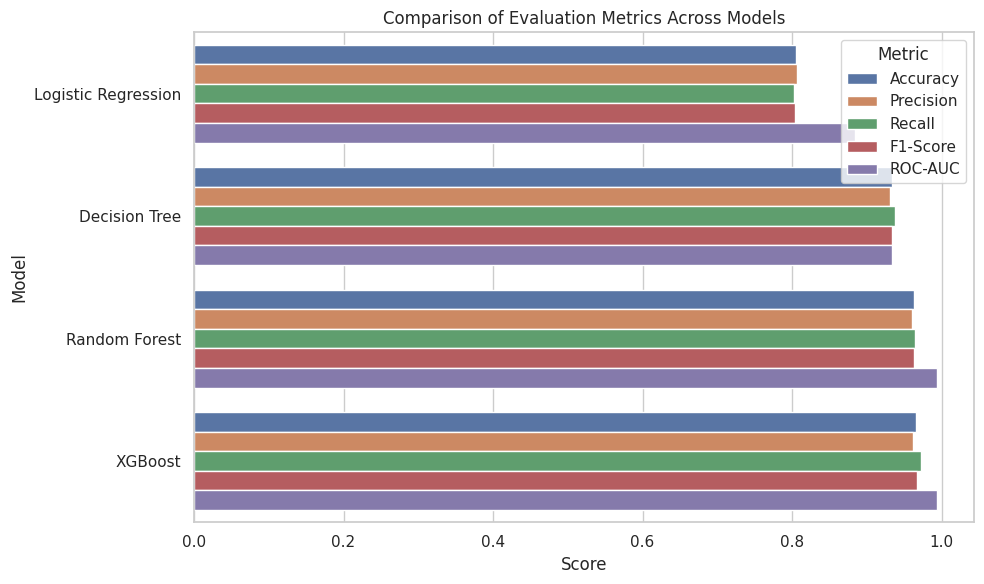

In [ ]:
# Plot Model Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df.melt(id_vars="Model"), x="value", y="Model", hue="variable")
plt.title("Comparison of Evaluation Metrics Across Models")
plt.xlabel("Score")
plt.ylabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


In [ ]:
# Highlight the best model by F1-Score (or any other metric)
best_df = results_df.sort_values(by="F1-Score", ascending=False)

def highlight_best(s):
    is_max = s == s.max()
    return ['background-color: green' if v else '' for v in is_max]

# Apply highlighting
styled = best_df.style.apply(highlight_best, subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])
styled


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,XGBoost,0.966317,0.961073,0.972003,0.966507,0.993604
2,Random Forest,0.962817,0.960801,0.965004,0.962898,0.993552
1,Decision Tree,0.933946,0.930556,0.937883,0.934205,0.933946
0,Logistic Regression,0.804899,0.806508,0.802275,0.804386,0.884585


In [ ]:
# Identify best model
best_model_name = results_df.loc[results_df["F1-Score"].idxmax(), "Model"]
print(f"Best Performing Model: {best_model}")

best_model = models[best_model_name]

Best Performing Model: RandomForestClassifier(bootstrap=False, max_depth=20, n_estimators=200,
                       random_state=42)


<ipython-input-46-b037a433e801>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='viridis')


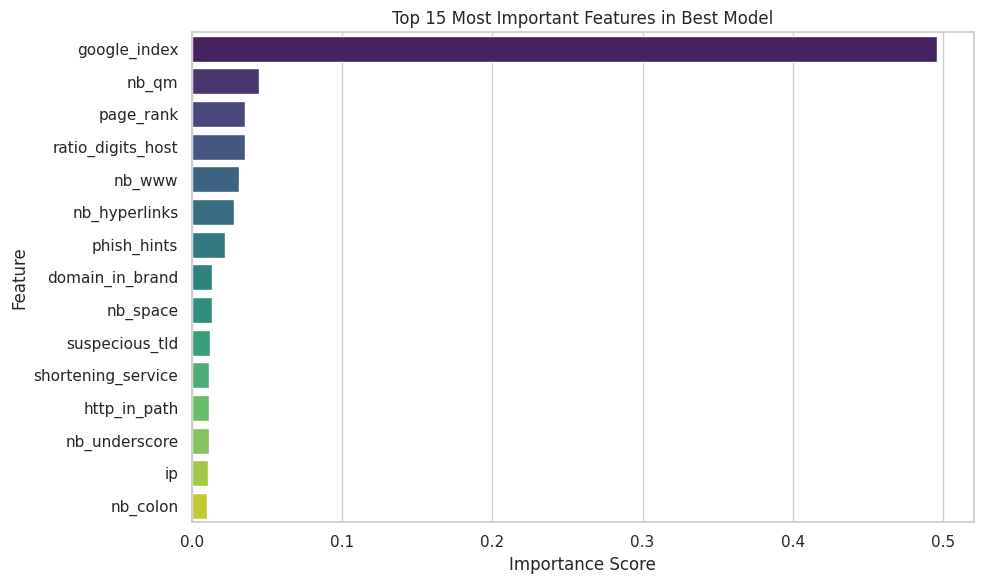

In [ ]:
# Assuming `best_model` is already your top model (e.g., from hyperparameter tuning or evaluation)
# For example, if XGBoost was the best:
# best_model = XGBClassifier(...).fit(X_train, y_train)

importances = best_model.feature_importances_
features = X_train.columns  # Ensure this matches your training data

# Create DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Top 15
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features in Best Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# Model Interpretation and Insights

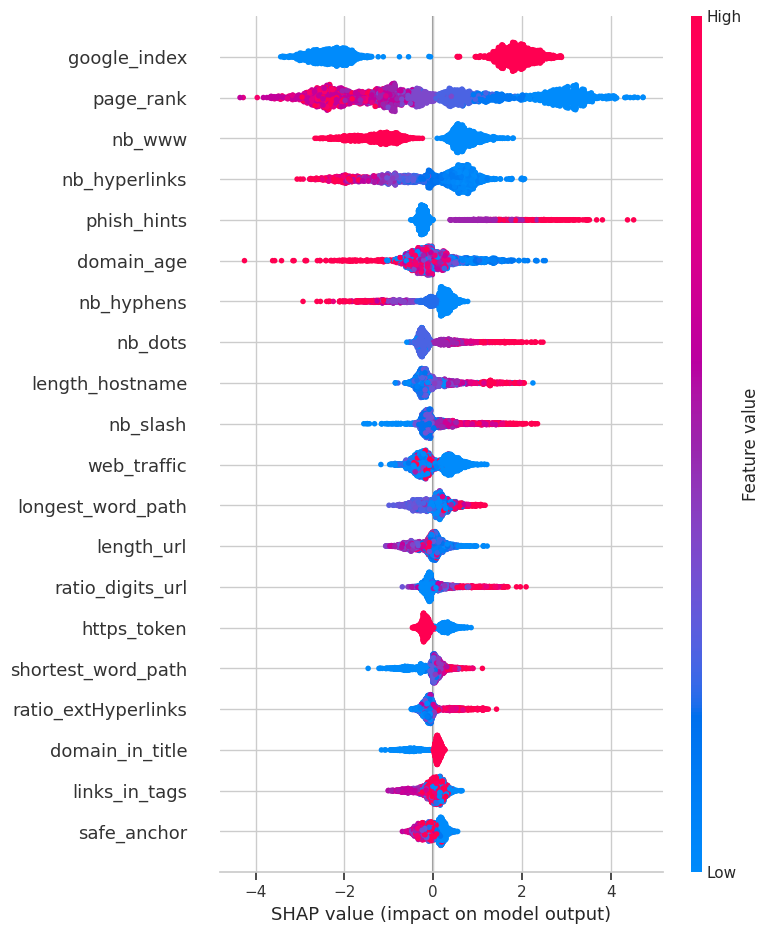

In [ ]:
import shap

# Create explainer and compute SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# For binary classification: use shap_values[1]
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

# Compute mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

# Mask of important features (non-zero mean impact)
important_features_mask = mean_abs_shap > 0

# Filter the dataset and SHAP values
X_test_filtered = X_test.loc[:, important_features_mask]
shap_vals_filtered = shap_vals[:, important_features_mask]

# Plot only features with non-zero SHAP importance
shap.summary_plot(shap_vals_filtered, X_test_filtered)


# Objective: Make the model interpretable and deployable.

Tasks:

*   Use SHAP or LIME to explain model predictions. ○

*   Deploy the model locally or on cloud platforms like AWS/GCP using Flask/Django.

Deliverables:

*   A deployed model endpoint.
*   Documentation on model interpretability and deployment steps.







# Model Explainability Report

In [ ]:
# Load Model and Dataset (Processed)
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import xgboost as xgb

# Load model and dataset
model = joblib.load('phishing_model_final.pkl')
data = pd.read_csv("dataset_phishing.csv")

# Drop unused or target column
X = data.drop(columns=['status', 'url'])  # assuming 'url' was dropped earlier
y = data['status']

# Scale the data if needed (based on previous preprocessing steps)

# Sample 1000 points for speed (optional)
X_sample = X.sample(1000, random_state=42)

<Figure size 640x480 with 0 Axes>

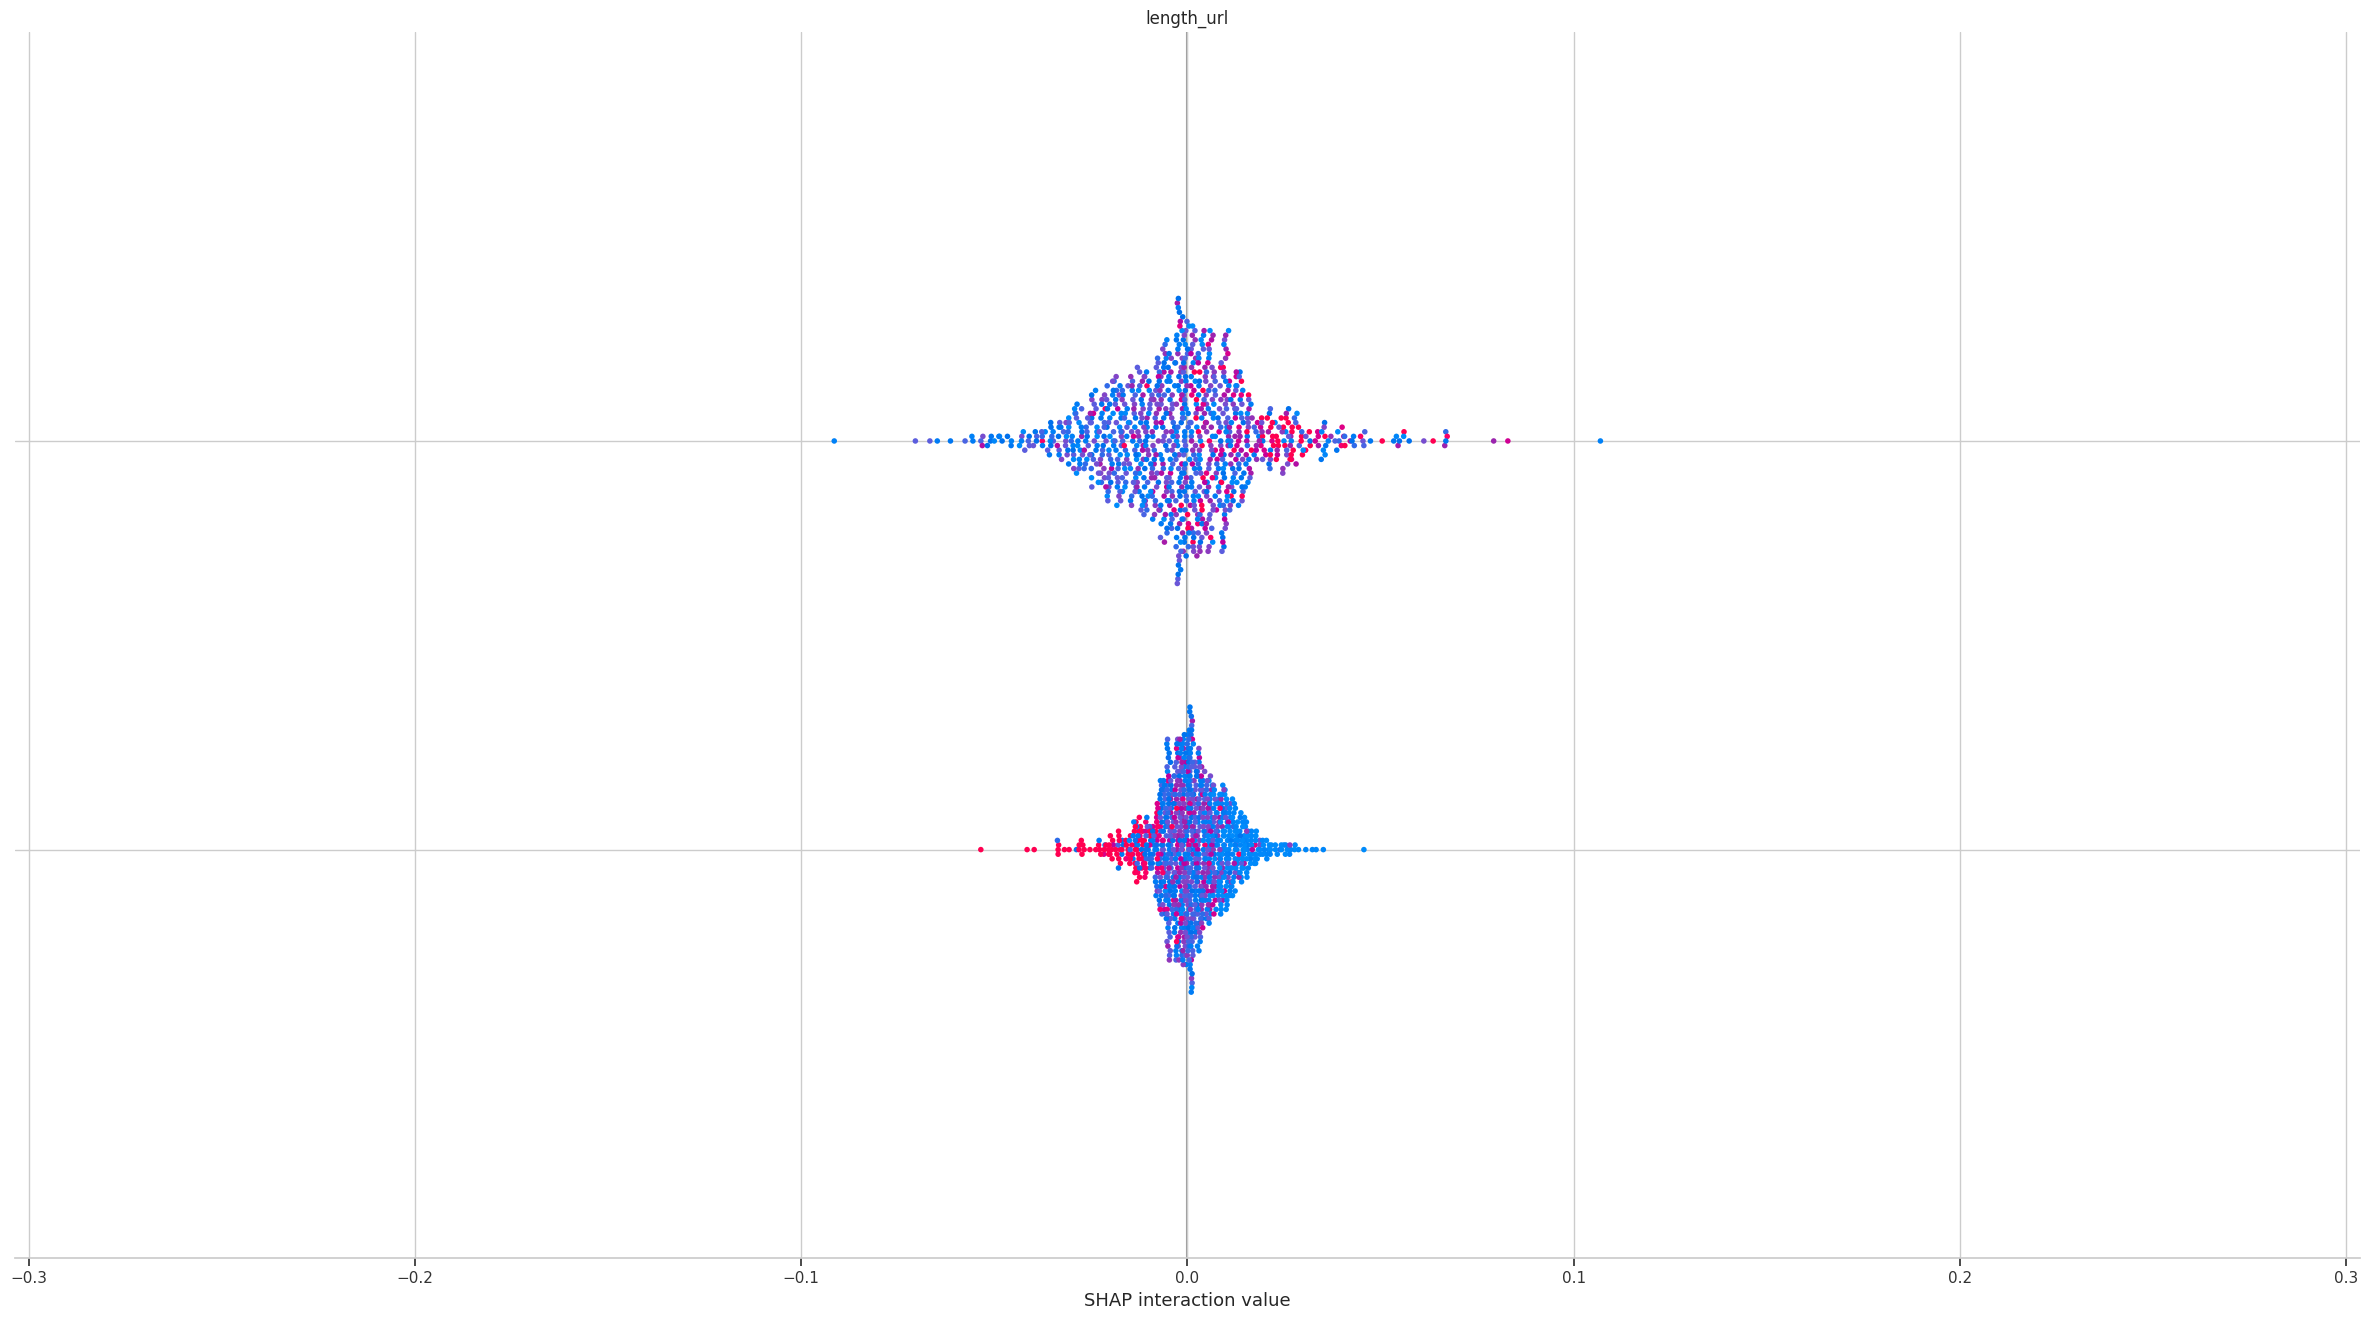

In [ ]:
# SHAP Summary Plot (Global Interpretability)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Summary Plot
shap.summary_plot(shap_values, X_sample, max_display=15)

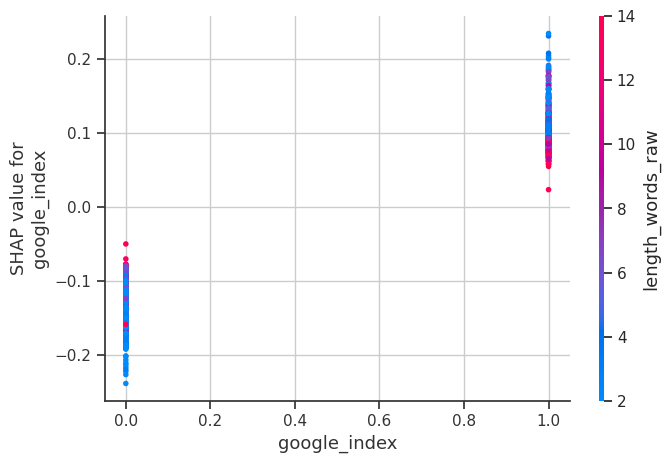

In [ ]:
# SHAP Dependence Plot (Feature Interaction)
shap.dependence_plot("google_index", shap_values[:, :, 1], X_sample)

In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=5e4c08025b78b36b34160377c8d426201c96c5f5baa84857fe59347471363133
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
# Fit LIME on the original (unscaled) data
explainer_lime = LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    class_names=['Legitimate', 'Phishing'],
    mode='classification'
)
# Explain a single prediction
i = 0  # Index of sample to explain
exp = explainer_lime.explain_instance(X.iloc[i].values, model.predict_proba)
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
